The project uses the YOLO OpenCV dataset from Kaggle to run object recognition. The YOLO OpenCV dataset contains several images that can be used in different works that are related to computer vision.

Import packages and models.

In [2]:
import os
import numpy as np
import cv2
import zipfile
import requests
import glob as glob

import tensorflow_hub as hub
import matplotlib
import matplotlib.pyplot as plt
import warnings
import logging
import absl

import pathlib
import random
import zipfile

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten
from tensorflow.keras.utils import image_dataset_from_directory

from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from dataclasses import dataclass

from zipfile import ZipFile
from urllib.request import urlretrieve

from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Activation
from keras.datasets.mnist import load_data

import json
import shutil
import pandas as pd

from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import tensorflow_hub as hub
from matplotlib.patches import Rectangle
from urllib.request import urlretrieve

# Filter absl warnings
warnings.filterwarnings("ignore", module="absl")

# Capture all warnings in the logging system
logging.captureWarnings(True)

# Set the absl logger level to 'error' to suppress warnings
absl_logger = logging.getLogger("absl")
absl_logger.setLevel(logging.ERROR)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [3]:
SEED_VALUE = 41

# Fix seed to make training deterministic.
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

Load the Kaggle Yolo OpenCV dataset.

In [4]:
def download_file(url, save_name):
    url = url
    file = requests.get(url)

    open(save_name, 'wb').write(file.content)

In [5]:
def unzip(zip_file=None):
    try:
        with zipfile.ZipFile(zip_file) as z:
            z.extractall("./")
            print("Extracted all")
    except:
        print("Invalid file")

In [6]:
KAGGLE_PATH = "/root/.kaggle"
if os.path.exists(KAGGLE_PATH):
  !rm -r "$KAGGLE_PATH"

!mkdir "$KAGGLE_PATH"
!touch "$KAGGLE_PATH/kaggle.json"

# https://www.kaggle.com/
api_token = {"username":"Colab_Keras","key":"KGAT_6c5e3427714f0b3f5fe56de3de7aa623"}

with open(KAGGLE_PATH+'/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("juniorbueno/yolo-opencv-images")

print("Path to dataset files:", path)

100%|██████████| 4.00M/4.00M [00:01<00:00, 2.81MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/juniorbueno/yolo-opencv-images/versions/1


In [9]:
# Print the contents of the downloaded directory to debug the missing file
print(f"Contents of the downloaded directory '{path}':")
!ls -F "{path}"

# Create a directory to extract the contents
# The path from kagglehub.model_download is a read-only directory.
# We need to create the directory in a writable location, such as /content/.
extracted_dir = os.path.join("/content", "YOLO OpenCV")
os.makedirs(extracted_dir, exist_ok=True)

# Extract the tar.gz file
# This part might be redundant if kagglehub.dataset_download already extracted it.
# We need to verify the file structure first.

print(f"Dataset extracted to: {extracted_dir}")

Contents of the downloaded directory '/root/.cache/kagglehub/datasets/juniorbueno/yolo-opencv-images/versions/1':
pictures/
Dataset extracted to: /content/YOLO OpenCV


Verify the presence of images in the specified file.

In [13]:
image_paths = sorted(glob.glob(os.path.join(path, "pictures", "*.jpg")))

if not image_paths:
    print(f"No images found in {os.path.join(path, 'pictures')}. Please verify the directory structure.")
else:
    for idx in range(len(image_paths)):
        print(image_paths[idx])

/root/.cache/kagglehub/datasets/juniorbueno/yolo-opencv-images/versions/1/pictures/135823006_3617820591676953_7827938331279060389_n.jpg
/root/.cache/kagglehub/datasets/juniorbueno/yolo-opencv-images/versions/1/pictures/140370219_2849441738716160_6749933501072316755_n.jpg
/root/.cache/kagglehub/datasets/juniorbueno/yolo-opencv-images/versions/1/pictures/2014_697258392-2014031382906.jpg_20140410.jpg
/root/.cache/kagglehub/datasets/juniorbueno/yolo-opencv-images/versions/1/pictures/2020-09-17-09-34-06-1200x800.jpg
/root/.cache/kagglehub/datasets/juniorbueno/yolo-opencv-images/versions/1/pictures/2020-09-17-09-41-51-1200x800.jpg
/root/.cache/kagglehub/datasets/juniorbueno/yolo-opencv-images/versions/1/pictures/7651-confira-as-racas-de-cachorro-medio-mais-articles_media_desktop-2.jpg
/root/.cache/kagglehub/datasets/juniorbueno/yolo-opencv-images/versions/1/pictures/CBPFOT050520160793-550x313.jpg
/root/.cache/kagglehub/datasets/juniorbueno/yolo-opencv-images/versions/1/pictures/CBPFOT2410201

In [14]:
def load_image(path):

    image = cv2.imread(path)

    # Convert image in BGR format to RGB.
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Add a batch dimension which is required by the model.
    image = np.expand_dims(image, axis=0)

    return image

In [15]:
images = []
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 15))

idx=0
for axis in ax.flat:
    image = load_image(image_paths[idx])
    images.append(image)
    axis.imshow(image[0])
    axis.axis('off')
    idx+=1

Output hidden; open in https://colab.research.google.com to view.

Create the class index with the colors.

In [51]:
class_names_mapping = {
         1: 'person',
         2: 'bicycle',
         3: 'car',
         4: 'motorcycle',
         5: 'airplane',
         6: 'bus',
         7: 'train',
         8: 'truck',
         9: 'boat',
         10: 'traffic light',
         11: 'fire hydrant',
         13: 'stop sign',
         14: 'parking meter',
         15: 'bench',
         16: 'bird',
         17: 'cat',
         18: 'dog',
         19: 'horse',
         20: 'sheep',
         21: 'cow',
         22: 'elephant',
         23: 'bear',
         24: 'zebra',
         25: 'giraffe',
         27: 'backpack',
         28: 'umbrella',
         31: 'handbag',
         32: 'tie',
         33: 'suitcase',
         34: 'frisbee',
         35: 'skis',
         36: 'snowboard',
         37: 'sports ball',
         38: 'kite',
         39: 'baseball bat',
         40: 'baseball glove',
         41: 'skateboard',
         42: 'surfboard',
         43: 'tennis racket',
         44: 'bottle',
         46: 'wine glass',
         47: 'cup',
         48: 'fork',
         49: 'knife',
         50: 'spoon',
         51: 'bowl',
         52: 'banana',
         53: 'apple',
         54: 'sandwich',
         55: 'orange',
         56: 'broccoli',
         57: 'carrot',
         58: 'hot dog',
         59: 'pizza',
         60: 'donut',
         61: 'cake',
         62: 'chair',
         63: 'couch',
         64: 'potted plant',
         65: 'bed',
         67: 'dining table',
         70: 'toilet',
         72: 'tv',
         73: 'laptop',
         74: 'mouse',
         75: 'remote',
         76: 'keyboard',
         77: 'cell phone',
         78: 'microwave',
         79: 'oven',
         80: 'toaster',
         81: 'sink',
         82: 'refrigerator',
         84: 'book',
         85: 'clock',
         86: 'vase',
         87: 'scissors',
         88: 'teddy bear',
         89: 'hair drier',
         90: 'toothbrush'
}

# Generate a colormap with enough distinct colors for our classes
num_classes = len(class_names_mapping)
colors_cmap = plt.get_cmap('tab20', num_classes)

# Create the class_index with colors in the format expected by class_to_rgb
class_index = {}
for class_id, name in class_names_mapping.items():
    rgb_float = colors_cmap(class_id)[:3] # Get R, G, B (ignore alpha) as floats 0-1
    rgb_int = tuple(map(int, (np.array(rgb_float) * 255))) # Convert to int 0-255
    class_index[class_id] = [rgb_int, name] # Format: [RGB_tuple, 'Class Name']

print("Updated class_index with RGB colors:")
for class_id, data in class_index.items():
    print(f"{class_id}: {data[0]} - {data[1]}")

Updated class_index with RGB colors:
1: (31, 119, 180) - person
2: (31, 119, 180) - bicycle
3: (31, 119, 180) - car
4: (174, 199, 232) - motorcycle
5: (174, 199, 232) - airplane
6: (174, 199, 232) - bus
7: (174, 199, 232) - train
8: (255, 127, 14) - truck
9: (255, 127, 14) - boat
10: (255, 127, 14) - traffic light
11: (255, 127, 14) - fire hydrant
13: (255, 187, 120) - stop sign
14: (255, 187, 120) - parking meter
15: (255, 187, 120) - bench
16: (44, 160, 44) - bird
17: (44, 160, 44) - cat
18: (44, 160, 44) - dog
19: (44, 160, 44) - horse
20: (152, 223, 138) - sheep
21: (152, 223, 138) - cow
22: (152, 223, 138) - elephant
23: (152, 223, 138) - bear
24: (214, 39, 40) - zebra
25: (214, 39, 40) - giraffe
27: (214, 39, 40) - backpack
28: (255, 152, 150) - umbrella
31: (255, 152, 150) - handbag
32: (148, 103, 189) - tie
33: (148, 103, 189) - suitcase
34: (148, 103, 189) - frisbee
35: (148, 103, 189) - skis
36: (197, 176, 213) - snowboard
37: (197, 176, 213) - sports ball
38: (197, 176, 213)

In [34]:
R = np.array(np.arange(96, 256, 32))
G = np.roll(R, 1)
B = np.roll(R, 2)

COLOR_IDS = np.array(np.meshgrid(R, G, B)).T.reshape(-1, 3)

We are going to use the EfficientDet model.

In [35]:
EfficientDet  = {'EfficientDet D0 512x512'   : 'https://tfhub.dev/tensorflow/efficientdet/d0/1',
                 'EfficientDet D1 640x640'   : 'https://tfhub.dev/tensorflow/efficientdet/d1/1',
                 'EfficientDet D2 768x768'   : 'https://tfhub.dev/tensorflow/efficientdet/d2/1',
                 'EfficientDet D3 896x896'   : 'https://tfhub.dev/tensorflow/efficientdet/d3/1',
                 'EfficientDet D4 1024x1024' : 'https://tfhub.dev/tensorflow/efficientdet/d4/1',
                 'EfficientDet D5 1280x1280' : 'https://tfhub.dev/tensorflow/efficientdet/d5/1',
                 'EfficientDet D6 1280x1280' : 'https://tfhub.dev/tensorflow/efficientdet/d6/1',
                 'EfficientDet D7 1536x1536' : 'https://tfhub.dev/tensorflow/efficientdet/d7/1'
                }


Load the D4 model.


In [36]:
model_url = EfficientDet['EfficientDet D4 1024x1024' ]

print('loading model: ', model_url)
od_model = hub.load(model_url)

print('\nmodel loaded!')

loading model:  https://tfhub.dev/tensorflow/efficientdet/d4/1

model loaded!


Apply the model to the YOLO OpenCV dataset.

In [37]:
# Call the model. # The model returns the detection results in the form of a dictionary.
results = od_model(images[0])

In [38]:
# Convert the dictionary values to numpy arrays.
results = {key:value.numpy() for key, value in results.items()}

In [39]:
# Print the keys from the results dictionary.
for key in results:
    print(key)

raw_detection_boxes
detection_multiclass_scores
detection_classes
detection_boxes
raw_detection_scores
num_detections
detection_anchor_indices
detection_scores


In [40]:
print('Num Raw Detections: ', (len(results['raw_detection_scores'][0])))
print('Num Detections:     ', (results['num_detections'][0]).astype(int))

Num Raw Detections:  196416
Num Detections:      100


In [41]:
# Print the Scores, Classes and Bounding Boxes for the detections.
num_dets = (results['num_detections'][0]).astype(int)

print('\nDetection Scores: \n\n', results['detection_scores'][0][0:num_dets])
print('\nDetection Classes: \n\n', results['detection_classes'][0][0:num_dets])
print('\nDetection Boxes: \n\n', results['detection_boxes'][0][0:num_dets])


Detection Scores: 

 [0.91692114 0.78652346 0.7098226  0.37007788 0.33037892 0.21957077
 0.17572908 0.15562269 0.13510625 0.09096076 0.06085076 0.06007798
 0.05909936 0.0566736  0.05421906 0.04858485 0.04779933 0.04443623
 0.04269169 0.04257518 0.04054221 0.03937584 0.0382995  0.03770882
 0.03739023 0.03699211 0.03675432 0.03642602 0.03631663 0.03590631
 0.03589707 0.03582769 0.03557358 0.03514683 0.03456391 0.03421097
 0.03337462 0.0332265  0.03298204 0.03239822 0.03219431 0.03126873
 0.03125556 0.03025278 0.0300769  0.03003176 0.02896005 0.02857207
 0.02844373 0.0275175  0.02750535 0.02748538 0.02733903 0.02696872
 0.02688398 0.02633042 0.02624962 0.02549129 0.02521029 0.02495853
 0.02457822 0.02457193 0.02454655 0.02422697 0.0240438  0.02395536
 0.02365112 0.02339384 0.02315868 0.02304443 0.02285876 0.02274143
 0.02273321 0.02256563 0.02237209 0.02210595 0.02188864 0.02171134
 0.02159245 0.02155577 0.0215138  0.02145882 0.02144559 0.02137917
 0.02130641 0.02118979 0.02112974 0.0208

Process the detection according to the classes defined in the class_index step.

In [48]:
def process_detection(image, results,  min_det_thresh=.3):

    # Extract the detection results from the results dictionary.
    scores  =  results['detection_scores'][0]
    boxes   =  results['detection_boxes'][0]
    classes = (results['detection_classes'][0]).astype(int)

    # Set a minimum detection threshold to post-process the detection results.
    min_det_thresh = min_det_thresh

    # Get the detections whose scores exceed the minimum detection threshold.
    det_indices = np.where(scores >= min_det_thresh)[0]

    scores_thresh  = scores[det_indices]
    boxes_thresh   = boxes[det_indices]
    classes_thresh = classes[det_indices]

    # Make a copy of the image to annotate.
    img_bbox = image.copy()

    im_height, im_width = image.shape[:2]

    font_scale = .6
    box_thickness = 2

    # Loop over all thresholded detections.
    for box, class_id, score in zip(boxes_thresh, classes_thresh, scores_thresh):

        # Get bounding box normalized coordiantes.
        ymin, xmin, ymax, xmax = box

        # Retrieve the class name from the class_index dictionary
        class_name = class_index[class_id][1]

        # Convert normalized bounding box coordinates to pixel coordinates.
        (left, right, top, bottom) = (int(xmin * im_width),
                                      int(xmax * im_width),
                                      int(ymin * im_height),
                                      int(ymax * im_height))

        # Annotate the image with the bounding box.
        # Use the RGB color from class_index directly
        color = class_index[class_id][0]
        img_bbox = cv2.rectangle(img_bbox, (left, top), (right, bottom), color, thickness=box_thickness)

        #-------------------------------------------------------------------
        # Annotate bounding box with detection data (class name and score).
        #-------------------------------------------------------------------

        # Build the text string that contains the class name and score associated with this detection.
        display_txt = '{}: {:.2f}%'.format(class_name, 100 * score)
        ((text_width, text_height), _) = cv2.getTextSize(display_txt, cv2.FONT_HERSHEY_SIMPLEX, font_scale, 1)

        # Handle case when the label is above the image frame.
        if top < text_height:
            shift_down = int(2*(1.3*text_height))
        else:
            shift_down = 0

        # Draw a filled rectangle on which the detection results will be displayed.
        img_bbox = cv2.rectangle(img_bbox,
                                 (left-1, top-box_thickness - int(1.3*text_height) + shift_down),
                                 (left-1 + int(1.1 * text_width), top),
                                 color,
                                 thickness=-1)

        # Annotate the filled rectangle with text (class label and score).
        img_bbox = cv2.putText(img_bbox,
                               display_txt,
                               (left + int(.05*text_width), top - int(0.2*text_height) + int(shift_down/2)),
                               cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 0, 0), 1)
    return img_bbox

Plot image with bounding boxes, labels and accuracy.

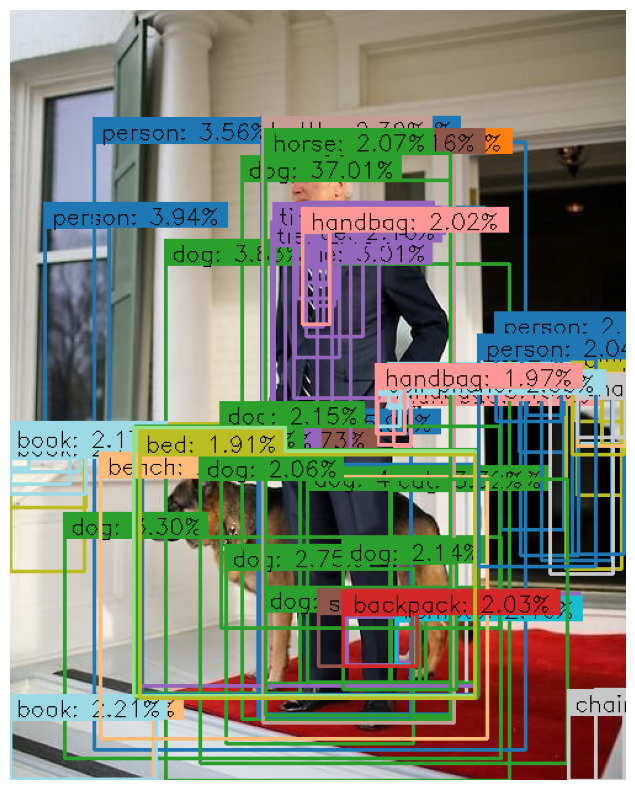

In [52]:
# Call the model.
results = od_model(images[0])

# Convert the dictionary values to numpy arrays.
results = {key:value.numpy() for key, value in results.items()}

# Remove the batch dimension from the first image.
image = np.squeeze(images[0])

# Process the first sample image.
img_bbox = process_detection(image, results, min_det_thresh=0)

plt.figure(figsize=[15, 10])
plt.imshow(img_bbox)
plt.axis('off');

Increase the threshold to 50% for accurate detection.

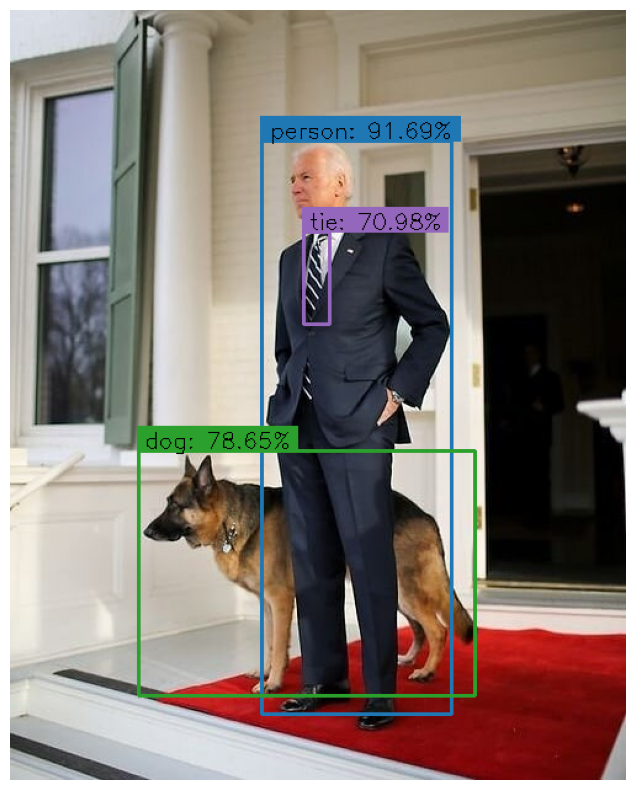

In [55]:
img_bbox = process_detection(image, results, min_det_thresh=.5)

plt.figure(figsize=[15, 10])
plt.imshow(img_bbox)
plt.axis('off');

Run inference on the model to loop between multiple pictures.

In [56]:
def run_inference(images, model):

    results_list = []
    for img in images:
        result = model(img)
        result = {key:value.numpy() for key,value in result.items()}

        results_list.append(result)

    return results_list

In [57]:
# Perform inference on each image and store the results in a list.
results_list = run_inference(images, od_model)

Print pictures with bounding boxes and labels. For functionality only 4 pictures have been chosen from the dataset to be processed.

In [58]:
for idx in range(len(images)):

    # Remove the batch dimension.
    image = np.squeeze(images[idx])

    # Generate the annotated image.
    image_bbox = process_detection(image, results_list[idx], min_det_thresh=.31)

    # Display annotated image.
    plt.figure(figsize=[20,10*len(images)])
    plt.subplot(len(images),1,idx+1)
    plt.imshow(image_bbox)
    plt.axis('off')

Output hidden; open in https://colab.research.google.com to view.